In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import scipy
import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

17-Dec-25 16:44:34 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


## load quantification files from relevant directories, and assemble into data frames

In [2]:
quantification_directory_1 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/250825_mACmChPOLR2A_BleachChase/20250828_191708_976/QUANTIFICATION/")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))

quantification_directory_2 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/250901_mACmChPOLR2A_BleachChase/20250904_183539_430/QUANTIFICATION/")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))

quantification_directory_3 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/250908_mACmChPOLR2A_BleachChase/20250911_183427_461/QUANTIFICATION/")
quantification_files_3 = glob.glob(str(quantification_directory_3 / "*.csv"))

len(quantification_files_1), len(quantification_files_2), len(quantification_files_3)

(144, 144, 136)

In [3]:
qdfs = list()


for f in tqdm(quantification_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[-8:-4] for f in files]
quantifcation_percell_1['fov'] = fovs

seq = [f[-13:-9] for f in files]
quantifcation_percell_1['seq'] = seq

100%|██████████| 144/144 [00:11<00:00, 12.79it/s]


In [4]:
qdfs2 = list()


for f in tqdm(quantification_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs2.append(data)

quantifcation_percell_2 = pd.concat(qdfs2, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[-8:-4] for f in files]
quantifcation_percell_2['fov'] = fovs

seq = [f[-13:-9] for f in files]
quantifcation_percell_2['seq'] = seq

100%|██████████| 144/144 [00:13<00:00, 10.44it/s]


In [5]:
qdfs3 = list()


for f in tqdm(quantification_files_3):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs3.append(data)

quantifcation_percell_3 = pd.concat(qdfs3, ignore_index=True)

files = quantifcation_percell_3['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_3['well'] = wellnames

fovs = [f[-8:-4] for f in files]
quantifcation_percell_3['fov'] = fovs

seq = [f[-13:-9] for f in files]
quantifcation_percell_3['seq'] = seq

100%|██████████| 136/136 [00:14<00:00,  9.16it/s]


In [6]:
Intensities_Rep1 = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "FOV" : quantifcation_percell_1['fov'],
    "SEQ" : quantifcation_percell_1['seq'],
    "RFP_561_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_AG_561'],
    "TIMEPOINT" : quantifcation_percell_1['TimepointID'],
    "NucleusArea" : quantifcation_percell_1['Nuclei_area']
})

seqs = ['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019']

prepost = ['Prebleach','Prebleach','Prebleach','Prebleach',
           'Prebleach','Prebleach','Prebleach','Prebleach',
           'Postbleach','Postbleach','Postbleach','Postbleach',
           'Postbleach','Postbleach','Postbleach','Postbleach']

bleachcontrol = ['Control','Control','Control','Control',
                 'Bleached','Bleached','Bleached','Bleached',
                 'Control','Control','Control','Control',
                 'Bleached','Bleached','Bleached','Bleached']

treatment = ['VEH', 'VEH', 'AUX', 'AUX',
             'VEH', 'VEH', 'AUX', 'AUX',
             'VEH', 'VEH', 'AUX', 'AUX',
             'VEH', 'VEH', 'AUX', 'AUX']

Intensities_Rep1['PrePost'] = Intensities_Rep1.SEQ.map(dict(zip(seqs,prepost)))
Intensities_Rep1['BleachControl'] = Intensities_Rep1.SEQ.map(dict(zip(seqs,bleachcontrol)))
Intensities_Rep1['Treatment'] = Intensities_Rep1.SEQ.map(dict(zip(seqs,treatment)))
Intensities_Rep1['TIME_MIN'] = 30*Intensities_Rep1.TIMEPOINT.astype(int)
Intensities_Rep1['TIME_HR'] = 0.5*Intensities_Rep1.TIMEPOINT.astype(int)

In [7]:
Intensities_Rep2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "FOV" : quantifcation_percell_2['fov'],
    "SEQ" : quantifcation_percell_2['seq'],
    "RFP_561_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_AG_561'],
    "TIMEPOINT" : quantifcation_percell_2['TimepointID'],
    "NucleusArea" : quantifcation_percell_2['Nuclei_area']
})

seqs = ['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019']

prepost = ['Prebleach','Prebleach','Prebleach','Prebleach',
           'Prebleach','Prebleach','Prebleach','Prebleach',
           'Postbleach','Postbleach','Postbleach','Postbleach',
           'Postbleach','Postbleach','Postbleach','Postbleach']

bleachcontrol = ['Control','Control','Control','Control',
                 'Bleached','Bleached','Bleached','Bleached',
                 'Control','Control','Control','Control',
                 'Bleached','Bleached','Bleached','Bleached']

treatment = ['AUX', 'AUX', 'VEH', 'VEH',
             'AUX', 'AUX', 'VEH', 'VEH',
             'AUX', 'AUX', 'VEH', 'VEH',
             'AUX', 'AUX', 'VEH', 'VEH']


Intensities_Rep2['PrePost'] = Intensities_Rep2.SEQ.map(dict(zip(seqs,prepost)))
Intensities_Rep2['BleachControl'] = Intensities_Rep2.SEQ.map(dict(zip(seqs,bleachcontrol)))
Intensities_Rep2['Treatment'] = Intensities_Rep2.SEQ.map(dict(zip(seqs,treatment)))
Intensities_Rep2['TIME_MIN'] = 30*Intensities_Rep2.TIMEPOINT.astype(int)
Intensities_Rep2['TIME_HR'] = 0.5*Intensities_Rep2.TIMEPOINT.astype(int)

In [8]:
Intensities_Rep3 = pd.DataFrame({
    "WELL" : quantifcation_percell_3['well'],
    "FOV" : quantifcation_percell_3['fov'],
    "SEQ" : quantifcation_percell_3['seq'],
    "RFP_561_Intensity" : quantifcation_percell_3['Nuclei_intensity_mean_AG_561'],
    "TIMEPOINT" : quantifcation_percell_3['TimepointID'],
    "NucleusArea" : quantifcation_percell_3['Nuclei_area']
})

seqs = ['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019']

prepost = ['Prebleach','Prebleach','Prebleach','Prebleach',
           'Prebleach','Prebleach','Prebleach','Prebleach',
           'Postbleach','Postbleach','Postbleach','Postbleach',
           'Postbleach','Postbleach','Postbleach','Postbleach']

bleachcontrol = ['Control','Control','Control','Control',
                 'Bleached','Bleached','Bleached','Bleached',
                 'Control','Control','Control','Control',
                 'Bleached','Bleached','Bleached','Bleached']

treatment = ['VEH', 'AUX', 'VEH', 'AUX',
             'VEH', 'AUX', 'VEH', 'AUX',
             'VEH', 'AUX', 'VEH', 'AUX',
             'VEH', 'AUX', 'VEH', 'AUX',]


Intensities_Rep3['PrePost'] = Intensities_Rep3.SEQ.map(dict(zip(seqs,prepost)))
Intensities_Rep3['BleachControl'] = Intensities_Rep3.SEQ.map(dict(zip(seqs,bleachcontrol)))
Intensities_Rep3['Treatment'] = Intensities_Rep3.SEQ.map(dict(zip(seqs,treatment)))
Intensities_Rep3['TIME_MIN'] = 30*Intensities_Rep3.TIMEPOINT.astype(int)
Intensities_Rep3['TIME_HR'] = 0.5*Intensities_Rep3.TIMEPOINT.astype(int)

In [9]:
#zero value measured from cell-free areas in sample image

## CHECK ZERO VALUES
# are these producing apparent change in auxin-induced RFP increase?


zero_val_1 = 157.2
zero_val_2 = 138.0
zero_val_3 = 150

In [10]:
Intensities_Rep1['RFP_BackgroundSubtracted'] = Intensities_Rep1['RFP_561_Intensity'] - zero_val_1
Intensities_Rep2['RFP_BackgroundSubtracted'] = Intensities_Rep2['RFP_561_Intensity'] - zero_val_2
Intensities_Rep3['RFP_BackgroundSubtracted'] = Intensities_Rep3['RFP_561_Intensity'] - zero_val_3

In [11]:
Intensities_Rep1['Experiment'] = '250825'
Intensities_Rep2['Experiment'] = '250901'
Intensities_Rep3['Experiment'] = '250908'
Intensities = pd.concat([Intensities_Rep1, Intensities_Rep2,Intensities_Rep3])

In [12]:
PrebleachIntensities = Intensities.query('PrePost == "Prebleach" & TIMEPOINT >= 6')

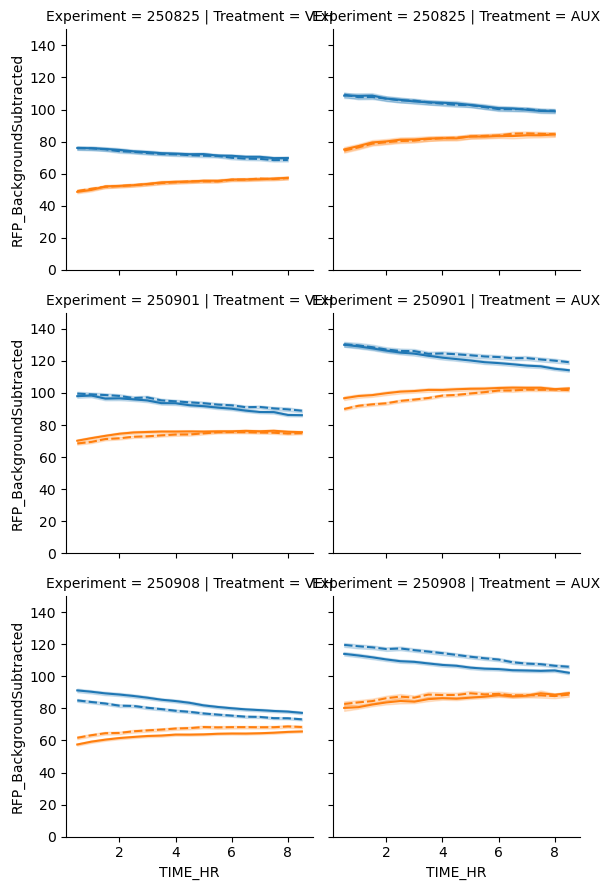

In [13]:
g = sns.FacetGrid(Intensities.query('PrePost != "Prebleach"'),
                  col = 'Treatment', col_order = ['VEH', 'AUX'],
                  row = 'Experiment',
                  ylim = (0,150))

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HR', 
                y = 'RFP_BackgroundSubtracted', 
                hue = 'BleachControl', hue_order = ['Control','Bleached'],
                style = 'WELL')

In [14]:
CountsByWell = Intensities.groupby(['Experiment','WELL','Treatment','PrePost','BleachControl','TIMEPOINT','TIME_MIN','TIME_HR']).count().reset_index()
CountsByWell['CellCount'] = CountsByWell['FOV']
CountsByWell['CellCountLog'] = np.log(CountsByWell['CellCount'])
CountsByWell.drop(['FOV', 'SEQ', 'RFP_561_Intensity', 'NucleusArea'],axis = 1, inplace = True)

In [15]:
CountsByWell = CountsByWell.query('PrePost == "Postbleach"')

In [16]:
ls = []

for e in CountsByWell.Experiment.unique():

    e_frame = CountsByWell[CountsByWell.Experiment == e]
    
    for c in CountsByWell.Treatment.unique():
    
        c_frame = e_frame[e_frame.Treatment == c]
    
        for b in CountsByWell.BleachControl.unique():
    
            b_frame = c_frame[c_frame.BleachControl == b]
    
            for w in b_frame.WELL.unique():
    
                w_frame = b_frame[b_frame.WELL == w]
    
                x_vals = w_frame.TIME_HR.tolist()
                y_vals = w_frame.CellCountLog.tolist()
        
                l = scipy.stats.linregress(x = x_vals, y = y_vals)
                keys = ["Experiment", "Well", "Treatment", "bleachcontrol", "slope", "intercept", "rvalue", "pvalue", "stderr", "intercept_stderr"]
                vals = [[e], [w], [c], [b], [l.slope], [l.intercept], [l.rvalue], [l.pvalue], [l.stderr], [l.intercept_stderr]]
        
                f = pd.DataFrame( dict(zip(keys,vals)) )
                ls.append(f)
        
GrowthRates = pd.concat(ls)

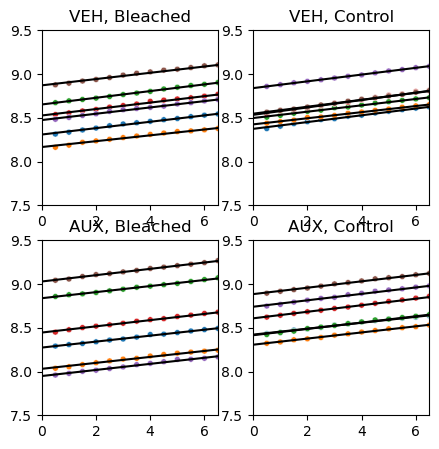

In [17]:
f, a = plt.subplots(ncols = 2, nrows = 2, figsize = (5,5))

ls = []

for e in CountsByWell.Experiment.unique():

    e_frame = CountsByWell[CountsByWell.Experiment == e]

    for t_i, c in enumerate(CountsByWell.Treatment.unique()):
    
        c_frame = e_frame[e_frame.Treatment == c]
    
        for r_i, b in enumerate(CountsByWell.BleachControl.unique()):
    
            b_frame = c_frame[c_frame.BleachControl == b]
    
            for w in b_frame.WELL.unique():
    
                w_frame = b_frame[b_frame.WELL == w]
    
                x_vals = w_frame.TIME_HR.tolist()
                y_vals = w_frame.CellCountLog.tolist()
        
                l = scipy.stats.linregress(x = x_vals, y = y_vals)
    
                sl = l.slope
                intr = l.intercept
    
                sns.scatterplot(x = x_vals, y = y_vals, ax = a[t_i, r_i], size = 4, legend = False)
                a[t_i, r_i].axline( (0,intr), slope = sl, color = 'black')
    
                a[t_i, r_i].set_xlim(0,6.5)
                a[t_i, r_i].set_ylim(7.5,9.5)

                a[t_i, r_i].set_title(str(c) + ', ' + str(b))



In [18]:
GrowthRates

,Experiment,Well,Treatment,bleachcontrol,slope,intercept,rvalue,pvalue,stderr,intercept_stderr
0,250825,C05,VEH,Bleached,0.036450,8.308665,0.996672,1.200595e-16,0.000797,0.003852
0,250825,C06,VEH,Bleached,0.033402,8.165783,0.993485,1.313290e-14,0.001024,0.004951
0,250825,C05,VEH,Control,0.038649,8.373685,0.996485,1.760238e-16,0.000868,0.004198
0,250825,C06,VEH,Control,0.034866,8.424764,0.998794,9.913072e-20,0.000458,0.002215
0,250825,C07,AUX,Bleached,0.034012,8.273868,0.998716,1.540718e-19,0.000461,0.002230
0,250825,C08,AUX,Bleached,0.034013,8.031037,0.995926,4.939839e-16,0.000823,0.003979
0,250825,C07,AUX,Control,0.033810,8.422095,0.997079,4.828321e-17,0.000692,0.003346
0,250825,C08,AUX,Control,0.035016,8.306603,0.998943,3.936804e-20,0.000431,0.002082
0,250901,C07,VEH,Bleached,0.038251,8.652069,0.999296,8.346604e-23,0.000371,0.001900
0,250901,C08,VEH,Bleached,0.036776,8.526332,0.997623,7.612512e-19,0.000656,0.003360


(0.0, 0.05)

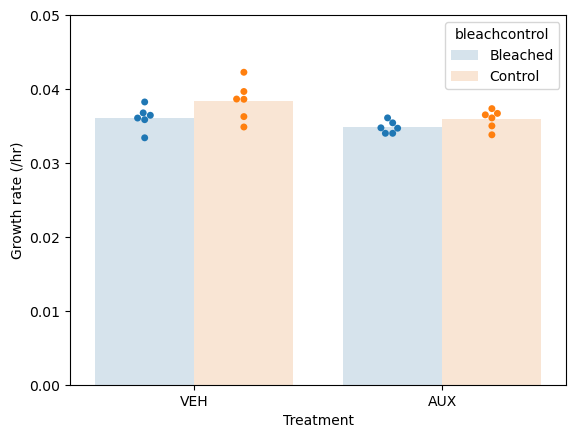

In [19]:
sns.swarmplot(GrowthRates,
              x = 'Treatment',
              y = 'slope',
              hue = 'bleachcontrol', dodge = True,
              legend = False)

sns.barplot(GrowthRates,
            x = 'Treatment',
            y = 'slope',
            hue = 'bleachcontrol', dodge = True,
            errorbar = None, alpha = 0.2)

plt.ylabel('Growth rate (/hr)')

plt.ylim(0,0.05)

In [20]:
Intensities.columns

Index(['WELL', 'FOV', 'SEQ', 'RFP_561_Intensity', 'TIMEPOINT', 'NucleusArea',
       'PrePost', 'BleachControl', 'Treatment', 'TIME_MIN', 'TIME_HR',
       'RFP_BackgroundSubtracted', 'Experiment'],
      dtype='object')

In [21]:
Intensities.PrePost.unique()

array(['Postbleach', 'Prebleach'], dtype=object)

In [22]:
IntensitiesPreBleach = Intensities.query('PrePost == "Prebleach"')
IntensitiesPostBleach = Intensities.query('PrePost == "Postbleach"')
                  
IntensitiesPostBleachMeans = IntensitiesPostBleach.drop(['TIME_MIN','TIMEPOINT','SEQ','FOV','PrePost'], axis = 1).groupby(['Experiment', 'WELL','BleachControl','Treatment','TIME_HR']).mean().reset_index()

In [23]:
IntensitiesPostBleachMeans['REPLICATE'] = IntensitiesPostBleachMeans['Experiment'] + '_' + IntensitiesPostBleachMeans['WELL']

In [24]:
IntensitiesPostBleachMeans 

,Experiment,WELL,BleachControl,Treatment,TIME_HR,RFP_561_Intensity,NucleusArea,RFP_BackgroundSubtracted,REPLICATE
0,250825,C05,Bleached,VEH,0.5,206.393741,1282.031380,49.193741,250825_C05
1,250825,C05,Bleached,VEH,1.0,207.800390,1290.057088,50.600390,250825_C05
2,250825,C05,Bleached,VEH,1.5,209.024192,1290.579317,51.824192,250825_C05
3,250825,C05,Bleached,VEH,2.0,209.459688,1286.645686,52.259688,250825_C05
4,250825,C05,Bleached,VEH,2.5,210.092784,1286.858480,52.892784,250825_C05
...,...,...,...,...,...,...,...,...,...
395,250908,C08,Control,AUX,6.5,253.796786,1387.113880,103.796786,250908_C08
396,250908,C08,Control,AUX,7.0,253.612550,1385.116583,103.612550,250908_C08
397,250908,C08,Control,AUX,7.5,253.409386,1382.602356,103.409386,250908_C08
398,250908,C08,Control,AUX,8.0,253.640810,1388.990443,103.640810,250908_C08


In [25]:
HundredVals = IntensitiesPreBleach.query('TIMEPOINT > 6').drop(['Treatment','FOV','SEQ','PrePost'],axis = 1).groupby(['Experiment','WELL','BleachControl']).mean().reset_index()

In [26]:
HundredVals

,Experiment,WELL,BleachControl,RFP_561_Intensity,TIMEPOINT,NucleusArea,TIME_MIN,TIME_HR,RFP_BackgroundSubtracted
0,250825,C05,Bleached,236.030918,7.503572,1278.535652,225.107157,3.751786,78.830918
1,250825,C05,Control,238.142905,7.504945,1291.096981,225.148362,3.752473,80.942905
2,250825,C06,Bleached,238.369448,7.507602,1239.898542,225.228048,3.753801,81.169448
3,250825,C06,Control,237.507846,7.505286,1298.868037,225.158570,3.752643,80.307846
4,250825,C07,Bleached,268.032133,7.505036,1333.019068,225.151068,3.752518,110.832133
5,250825,C07,Control,270.946198,7.505399,1299.425537,225.161979,3.752700,113.746198
6,250825,C08,Bleached,271.379798,7.505042,1327.479659,225.151252,3.752521,114.179798
7,250825,C08,Control,270.075525,7.504490,1313.651611,225.134707,3.752245,112.875525
8,250901,C05,Bleached,265.620467,7.504317,1325.799611,225.129522,3.752159,127.620467
9,250901,C05,Control,273.226211,7.506886,1268.673834,225.206572,3.753443,135.226211


In [27]:
def norm(a,b,c,d):
    hv = HundredVals[(HundredVals['Experiment'] == a) & (HundredVals['WELL'] == b) & (HundredVals['BleachControl'] == c)].RFP_BackgroundSubtracted.values[0]

    nv = d / hv

    return nv

In [28]:
IntensitiesPostBleachMeans['RFP_Normed'] = IntensitiesPostBleachMeans.apply(lambda x: norm(x.Experiment, x.WELL, x.BleachControl, x.RFP_BackgroundSubtracted), axis=1)

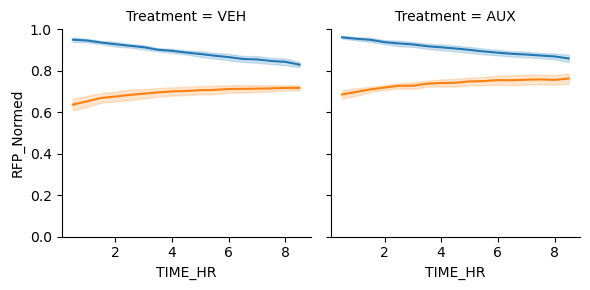

In [29]:
g = sns.FacetGrid(IntensitiesPostBleachMeans, 
                  col = 'Treatment', col_order = ['VEH', 'AUX'],
                  ylim = (0,1))

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HR', 
                y = 'RFP_Normed', 
                hue = 'BleachControl', hue_order = ['Control','Bleached'],
                errorbar = 'sd')

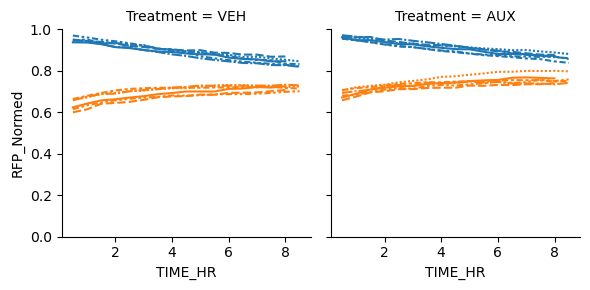

In [30]:
g = sns.FacetGrid(IntensitiesPostBleachMeans, 
                  col = 'Treatment', col_order = ['VEH', 'AUX'],
                  ylim = (0,1))

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HR', 
                y = 'RFP_Normed', 
                hue = 'BleachControl', hue_order = ['Control','Bleached'],
                style = 'REPLICATE')

In [31]:
VehHundredVals = IntensitiesPreBleach.query('TIMEPOINT > 6 & Treatment == "VEH"').drop(['WELL','FOV','SEQ','PrePost','BleachControl'],axis = 1).groupby(['Experiment','Treatment']).mean().reset_index()

In [32]:
def norm_to_veh(a,b):
    hv = VehHundredVals[(VehHundredVals['Experiment'] == a)].RFP_BackgroundSubtracted.values[0]

    nv = b / hv

    return nv

In [33]:
IntensitiesPostBleachMeans['RFP_Normed_ToVeh'] = IntensitiesPostBleachMeans.apply(lambda x: norm_to_veh(x.Experiment, x.RFP_BackgroundSubtracted), axis=1)

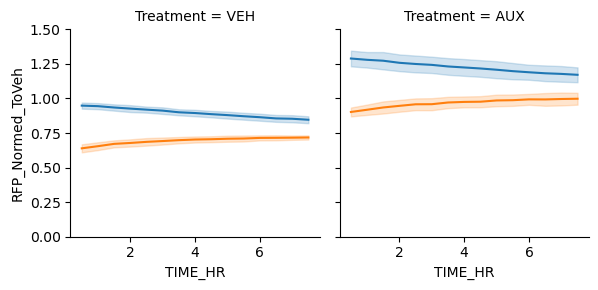

In [34]:
g = sns.FacetGrid(IntensitiesPostBleachMeans.query('TIME_HR < 8'), 
                  col = 'Treatment', col_order = ['VEH', 'AUX'],
                  ylim = (0,1.5))

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HR', 
                y = 'RFP_Normed_ToVeh', 
                hue = 'BleachControl', hue_order = ['Control','Bleached'],
                errorbar = 'sd')

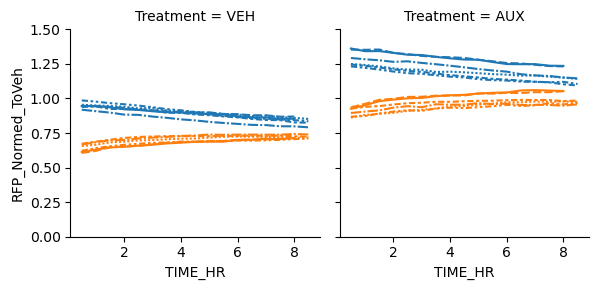

In [35]:
g = sns.FacetGrid(IntensitiesPostBleachMeans, 
                  col = 'Treatment', col_order = ['VEH', 'AUX'],
                  ylim = (0,1.5))

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HR', 
                y = 'RFP_Normed_ToVeh', 
                hue = 'BleachControl', hue_order = ['Control','Bleached'],
                style = 'REPLICATE')

In [36]:
dfs = []

for e in IntensitiesPostBleachMeans.Experiment.unique():
    
    e_frame = IntensitiesPostBleachMeans[IntensitiesPostBleachMeans['Experiment'] == e]
    
    for t in IntensitiesPostBleachMeans.Treatment.unique():
    
        t_frame = e_frame[e_frame['Treatment'] == t]
    
        for w_i,w in enumerate(t_frame.WELL.unique()):
    
            w_frame = t_frame[t_frame.WELL == w]
        
            bl = np.asarray(w_frame.query('BleachControl == "Bleached"').RFP_Normed.tolist())
            ctr = np.asarray(w_frame.query('BleachControl == "Control"').RFP_Normed.tolist())
        
            rt = ctr - bl
            
            tm = w_frame.query('BleachControl == "Bleached"').TIME_HR.tolist()

            rpl = w_frame.REPLICATE.unique()[0]
        
            df = pd.DataFrame({'Experiment' : e,
                              'Treatment' : np.tile(t, len(rt)),
                               'Well' : np.tile(w, len(rt)),
                               'Replicate' : np.tile(rpl, len(rt)),
                               'Time_hr' : tm,
                               'SubtractedIntensity' : rt
                              })
            dfs.append(df)

NormalisedIntensities = pd.concat(dfs)
NormalisedIntensities['Log_SubtractedIntensity'] = np.log(NormalisedIntensities['SubtractedIntensity'])

<Axes: xlabel='Time_hr', ylabel='Log_SubtractedIntensity'>

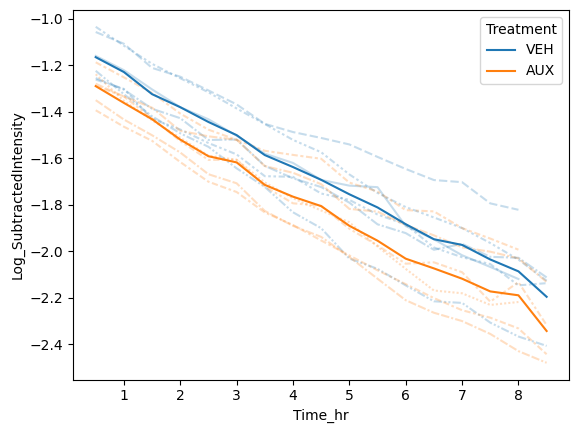

In [37]:
sns.lineplot(NormalisedIntensities,
             x = 'Time_hr',
             y = 'Log_SubtractedIntensity', 
             hue = 'Treatment', hue_order = ['VEH', 'AUX'],
             style = 'Replicate',
             alpha = 0.25,
             legend = False)

sns.lineplot(NormalisedIntensities,
             x = 'Time_hr',
             y = 'Log_SubtractedIntensity', 
             hue = 'Treatment', hue_order = ['VEH', 'AUX'],
             errorbar = None)

<Axes: xlabel='Time_hr', ylabel='Log_SubtractedIntensity'>

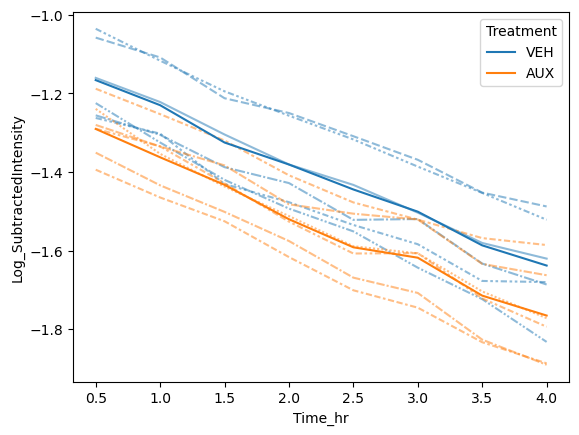

In [38]:
NormalisedIntensities = NormalisedIntensities.query('Time_hr < = 4')

sns.lineplot(NormalisedIntensities,
             x = 'Time_hr',
             y = 'Log_SubtractedIntensity', 
             hue = 'Treatment', hue_order = ['VEH', 'AUX'],
             style = 'Replicate',
             alpha = 0.5,
             legend = False)

sns.lineplot(NormalisedIntensities,
             x = 'Time_hr',
             y = 'Log_SubtractedIntensity', 
             hue = 'Treatment', hue_order = ['VEH', 'AUX'],
             errorbar = None)

In [39]:
ls = []

for e in NormalisedIntensities.Experiment.unique():
    
    e_frame = NormalisedIntensities[NormalisedIntensities['Experiment'] == e]
    
    for t in NormalisedIntensities.Treatment.unique():
    
        t_frame = e_frame[e_frame['Treatment'] == t]

        for r in t_frame.Replicate.unique():

            r_frame = t_frame[t_frame.Replicate == r]

            w = r_frame.Well.unique()[0]

            x_vals = r_frame.Time_hr.tolist()
            y_vals = r_frame.SubtractedIntensity.tolist()
            y_vals_log = np.log(y_vals)
            
            l = scipy.stats.linregress(x = x_vals, y = y_vals_log)
            keys = ["Experiment", "Well", "Replicate", "Treatment", "slope", "intercept", "rvalue", "pvalue", "stderr", "intercept_stderr"]
            vals = [[e], [w], [r],[t],[l.slope], [l.intercept], [l.rvalue], [l.pvalue], [l.stderr], [l.intercept_stderr]]
            f = pd.DataFrame( dict(zip(keys,vals)) )
            ls.append(f)

RegressionResults = pd.concat(ls)

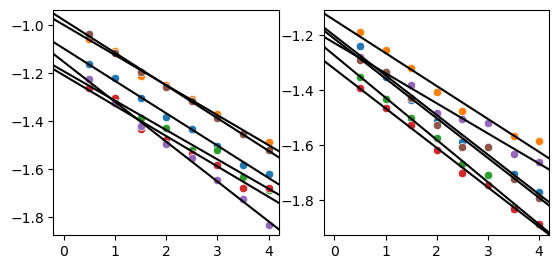

In [40]:
f, a = plt.subplots(ncols = 2)

for e in NormalisedIntensities.Experiment.unique():
    
    e_frame = NormalisedIntensities[NormalisedIntensities['Experiment'] == e]
    
    for t in NormalisedIntensities.Treatment.unique():
    
        t_frame = e_frame[e_frame['Treatment'] == t]

        for r in t_frame.Replicate.unique():

            r_frame = t_frame[t_frame.Replicate == r]

            w = r_frame.Well.unique()[0]

            x_vals = r_frame.Time_hr.tolist()
            y_vals = r_frame.Log_SubtractedIntensity.tolist()
            
            l = scipy.stats.linregress(x = x_vals, y = y_vals)
            i = l.intercept
            s = l.slope

            if t == "VEH":
                axn = 0
            elif t == "AUX":
                axn = 1

            sns.scatterplot(x = x_vals, y = y_vals, ax = a[axn])
            a[axn].axline( (0, i) , slope=s, color='black')
            a[axn].set_box_aspect(1)

RegressionResults = pd.concat(ls)

In [41]:
RegressionResults

,Experiment,Well,Replicate,Treatment,slope,intercept,rvalue,pvalue,stderr,intercept_stderr
0,250825,C05,250825_C05,VEH,-0.134828,-1.097395,-0.998068,1.800686e-08,0.003427,0.008652
0,250825,C06,250825_C06,VEH,-0.125180,-0.999272,-0.995974,1.626450e-07,0.004600,0.011614
0,250825,C07,250825_C07,AUX,-0.144458,-1.201894,-0.991885,1.327888e-06,0.007559,0.019086
0,250825,C08,250825_C08,AUX,-0.119899,-1.145585,-0.987435,4.912676e-06,0.007834,0.019779
0,250901,C07,250901_C07,VEH,-0.122427,-1.191922,-0.991794,1.373013e-06,0.006443,0.016267
0,250901,C08,250901_C08,VEH,-0.126596,-1.208825,-0.987149,5.255134e-06,0.008367,0.021125
0,250901,C05,250901_C05,AUX,-0.153713,-1.273779,-0.997673,3.145785e-08,0.004289,0.010829
0,250901,C06,250901_C06,AUX,-0.143719,-1.322705,-0.998121,1.656281e-08,0.003602,0.009094
0,250908,C05,250908_C05,VEH,-0.166120,-1.153042,-0.997869,2.413836e-08,0.004434,0.011195
0,250908,C07,250908_C07,VEH,-0.136216,-0.978823,-0.999201,1.276483e-09,0.002225,0.005618


In [42]:
GrowthRates

,Experiment,Well,Treatment,bleachcontrol,slope,intercept,rvalue,pvalue,stderr,intercept_stderr
0,250825,C05,VEH,Bleached,0.036450,8.308665,0.996672,1.200595e-16,0.000797,0.003852
0,250825,C06,VEH,Bleached,0.033402,8.165783,0.993485,1.313290e-14,0.001024,0.004951
0,250825,C05,VEH,Control,0.038649,8.373685,0.996485,1.760238e-16,0.000868,0.004198
0,250825,C06,VEH,Control,0.034866,8.424764,0.998794,9.913072e-20,0.000458,0.002215
0,250825,C07,AUX,Bleached,0.034012,8.273868,0.998716,1.540718e-19,0.000461,0.002230
0,250825,C08,AUX,Bleached,0.034013,8.031037,0.995926,4.939839e-16,0.000823,0.003979
0,250825,C07,AUX,Control,0.033810,8.422095,0.997079,4.828321e-17,0.000692,0.003346
0,250825,C08,AUX,Control,0.035016,8.306603,0.998943,3.936804e-20,0.000431,0.002082
0,250901,C07,VEH,Bleached,0.038251,8.652069,0.999296,8.346604e-23,0.000371,0.001900
0,250901,C08,VEH,Bleached,0.036776,8.526332,0.997623,7.612512e-19,0.000656,0.003360


In [43]:
RegressionResults['RemovalRate_perhr'] = -1*RegressionResults['slope']
GrowthRates = GrowthRates.rename(columns = {'slope' : 'GrowthRate_perhr'})
Rates = GrowthRates.query('bleachcontrol == "Bleached"')[['Experiment','Well','Treatment','GrowthRate_perhr']].merge(RegressionResults[['Experiment','Well','Treatment','RemovalRate_perhr']])
Rates['DegradationRate_perhr'] = Rates['RemovalRate_perhr'] - Rates['GrowthRate_perhr']
Rates['half-life (hr)'] = np.log(2) / Rates['DegradationRate_perhr']

In [44]:
Rates

,Experiment,Well,Treatment,GrowthRate_perhr,RemovalRate_perhr,DegradationRate_perhr,half-life (hr)
0,250825,C05,VEH,0.036450,0.134828,0.098378,7.045787
1,250825,C06,VEH,0.033402,0.125180,0.091778,7.552451
2,250825,C07,AUX,0.034012,0.144458,0.110445,6.275929
3,250825,C08,AUX,0.034013,0.119899,0.085886,8.070582
4,250901,C07,VEH,0.038251,0.122427,0.084176,8.234492
5,250901,C08,VEH,0.036776,0.126596,0.089820,7.717061
6,250901,C05,AUX,0.034703,0.153713,0.119010,5.824253
7,250901,C06,AUX,0.035427,0.143719,0.108292,6.400704
8,250908,C05,VEH,0.036078,0.166120,0.130042,5.330168
9,250908,C07,VEH,0.035856,0.136216,0.100360,6.906605


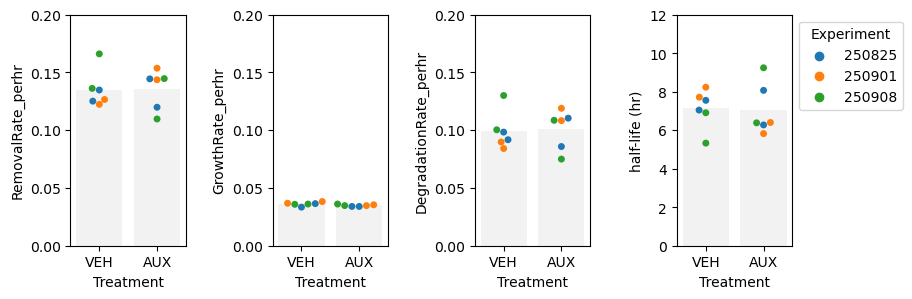

In [45]:
f, a = plt.subplots(ncols = 4, figsize = (10,3))

h = sns.swarmplot(Rates, x = 'Treatment', y = 'RemovalRate_perhr', ax = a[0], hue = 'Experiment', legend = None)
sns.barplot(Rates, x = 'Treatment', y = 'RemovalRate_perhr', ax = a[0], errorbar = None, alpha = 0.1, color = 'grey')
h.set_box_aspect(2)

h = sns.swarmplot(Rates, x = 'Treatment', y = 'GrowthRate_perhr', ax = a[1], hue = 'Experiment', legend = None)
sns.barplot(Rates, x = 'Treatment', y = 'GrowthRate_perhr', ax = a[1], errorbar = None, alpha = 0.1, color = 'grey')
h.set_box_aspect(2)

h = sns.swarmplot(Rates, x = 'Treatment', y = 'DegradationRate_perhr', ax = a[2], hue = 'Experiment', legend = None)
sns.barplot(Rates, x = 'Treatment', y = 'DegradationRate_perhr', ax = a[2], errorbar = None, alpha = 0.1, color = 'grey')
h.set_box_aspect(2)

h = sns.swarmplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[3], hue = 'Experiment')
sns.barplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[3], errorbar = None, alpha = 0.1, color = 'grey')
h.set_box_aspect(2)
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
a[3].set_ylim(0,12)

for i in range(3):
    a[i].set_ylim(0,0.2)
    a[i].set_yticks([0, 0.05, 0.1, 0.15, 0.2])

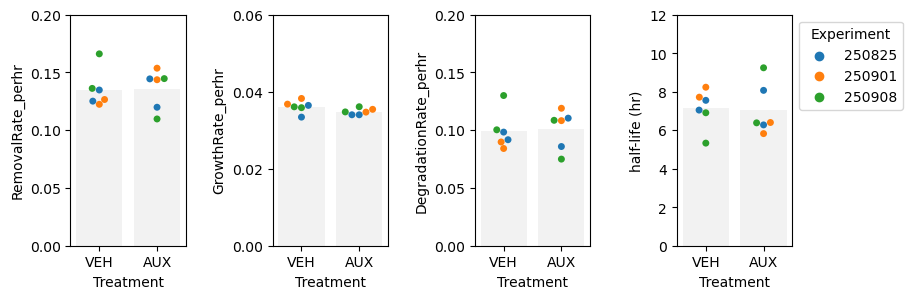

In [46]:
f, a = plt.subplots(ncols = 4, figsize = (10,3))

h = sns.swarmplot(Rates, x = 'Treatment', y = 'RemovalRate_perhr', ax = a[0], hue = 'Experiment', legend = None)
sns.barplot(Rates, x = 'Treatment', y = 'RemovalRate_perhr', ax = a[0], errorbar = None, alpha = 0.1, color = 'grey')
h.set_box_aspect(2)

h = sns.swarmplot(Rates, x = 'Treatment', y = 'GrowthRate_perhr', ax = a[1], hue = 'Experiment', legend = None)
sns.barplot(Rates, x = 'Treatment', y = 'GrowthRate_perhr', ax = a[1], errorbar = None, alpha = 0.1, color = 'grey')
h.set_box_aspect(2)

h = sns.swarmplot(Rates, x = 'Treatment', y = 'DegradationRate_perhr', ax = a[2], hue = 'Experiment', legend = None)
sns.barplot(Rates, x = 'Treatment', y = 'DegradationRate_perhr', ax = a[2], errorbar = None, alpha = 0.1, color = 'grey')
h.set_box_aspect(2)

h = sns.swarmplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[3], hue = 'Experiment')
sns.barplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[3], errorbar = None, alpha = 0.1, color = 'grey')
h.set_box_aspect(2)
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
a[3].set_ylim(0,12)

for i in range(3):
    a[i].set_ylim(0,0.2)
    a[i].set_yticks([0, 0.05, 0.1, 0.15, 0.2])

a[1].set_ylim(0,0.06)
a[1].set_yticks([0, 0.02, 0.04, 0.06]);

In [47]:
IntensitiesPreBleach

,WELL,FOV,SEQ,RFP_561_Intensity,TIMEPOINT,NucleusArea,PrePost,BleachControl,Treatment,TIME_MIN,TIME_HR,RFP_BackgroundSubtracted,Experiment
5271,C05,0005,0004,183.921429,1,1820.0,Prebleach,Bleached,VEH,30,0.5,26.721429,250825
5272,C05,0005,0004,202.099085,1,656.0,Prebleach,Bleached,VEH,30,0.5,44.899085,250825
5273,C05,0005,0004,208.576834,1,1295.0,Prebleach,Bleached,VEH,30,0.5,51.376834,250825
5274,C05,0005,0004,204.584042,1,1529.0,Prebleach,Bleached,VEH,30,0.5,47.384042,250825
5275,C05,0005,0004,230.074627,1,1206.0,Prebleach,Bleached,VEH,30,0.5,72.874627,250825
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1317477,C06,0008,0005,306.494715,8,473.0,Prebleach,Bleached,AUX,240,4.0,156.494715,250908
1317478,C06,0008,0005,268.530220,8,1092.0,Prebleach,Bleached,AUX,240,4.0,118.530220,250908
1317479,C06,0008,0005,325.562212,8,868.0,Prebleach,Bleached,AUX,240,4.0,175.562212,250908
1317480,C06,0008,0005,321.758929,8,112.0,Prebleach,Bleached,AUX,240,4.0,171.758929,250908


In [48]:
IntensitiesPreBleach.query('TIMEPOINT > 6')[['WELL','Treatment','RFP_BackgroundSubtracted']].groupby(['WELL','Treatment']).mean().groupby('Treatment').mean()

,RFP_BackgroundSubtracted
Treatment,
AUX,121.977255
VEH,92.586019


In [49]:
fold_increase_auxin = 123.212582 / 92.339730

In [50]:
baseline_removal_rate = Rates.query('Treatment == "VEH"')['RemovalRate_perhr'].mean()

In [51]:
baseline_removal_rate

0.13522806244499022

In [52]:
necessary_removal_rate = baseline_removal_rate / fold_increase_auxin

In [53]:
Rates

,Experiment,Well,Treatment,GrowthRate_perhr,RemovalRate_perhr,DegradationRate_perhr,half-life (hr)
0,250825,C05,VEH,0.036450,0.134828,0.098378,7.045787
1,250825,C06,VEH,0.033402,0.125180,0.091778,7.552451
2,250825,C07,AUX,0.034012,0.144458,0.110445,6.275929
3,250825,C08,AUX,0.034013,0.119899,0.085886,8.070582
4,250901,C07,VEH,0.038251,0.122427,0.084176,8.234492
5,250901,C08,VEH,0.036776,0.126596,0.089820,7.717061
6,250901,C05,AUX,0.034703,0.153713,0.119010,5.824253
7,250901,C06,AUX,0.035427,0.143719,0.108292,6.400704
8,250908,C05,VEH,0.036078,0.166120,0.130042,5.330168
9,250908,C07,VEH,0.035856,0.136216,0.100360,6.906605


In [54]:
necessary_degradation_rate = necessary_removal_rate - Rates['GrowthRate_perhr'].mean()

In [55]:
necessary_half_life = np.log(2) / necessary_degradation_rate

In [56]:
baseline_half_life = Rates.query('Treatment == "VEH"')['half-life (hr)'].mean()

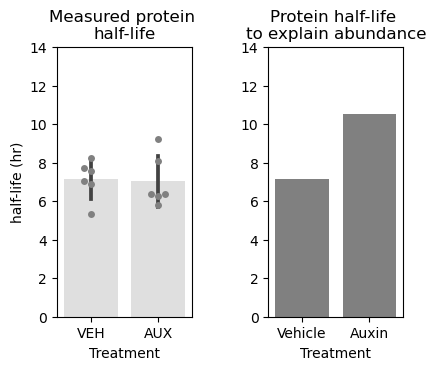

In [57]:
f, a = plt.subplots(ncols = 2, figsize = (5,3.5))



h = sns.swarmplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[0], color = 'grey')
sns.barplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[0], errorbar = 'sd', alpha = 0.25, color = 'grey')
h.set_box_aspect(2)


h = sns.barplot(x = ['Vehicle', 'Auxin'],
            y = [baseline_half_life,necessary_half_life],
            ax = a[1],
                color = 'grey')
h.set_box_aspect(2)

a[1].set_xlabel('Treatment')

a[0].set_ylim(0,14)
a[1].set_ylim(0,14)

a[0].set_title('Measured protein \nhalf-life')
a[1].set_title('Protein half-life \nto explain abundance');


In [58]:
IntensitiesPostBleachMeans

,Experiment,WELL,BleachControl,Treatment,TIME_HR,RFP_561_Intensity,NucleusArea,RFP_BackgroundSubtracted,REPLICATE,RFP_Normed,RFP_Normed_ToVeh
0,250825,C05,Bleached,VEH,0.5,206.393741,1282.031380,49.193741,250825_C05,0.624041,0.612681
1,250825,C05,Bleached,VEH,1.0,207.800390,1290.057088,50.600390,250825_C05,0.641885,0.630200
2,250825,C05,Bleached,VEH,1.5,209.024192,1290.579317,51.824192,250825_C05,0.657409,0.645442
3,250825,C05,Bleached,VEH,2.0,209.459688,1286.645686,52.259688,250825_C05,0.662934,0.650866
4,250825,C05,Bleached,VEH,2.5,210.092784,1286.858480,52.892784,250825_C05,0.670965,0.658751
...,...,...,...,...,...,...,...,...,...,...,...
395,250908,C08,Control,AUX,6.5,253.796786,1387.113880,103.796786,250908_C08,0.870225,1.121897
396,250908,C08,Control,AUX,7.0,253.612550,1385.116583,103.612550,250908_C08,0.868680,1.119905
397,250908,C08,Control,AUX,7.5,253.409386,1382.602356,103.409386,250908_C08,0.866977,1.117709
398,250908,C08,Control,AUX,8.0,253.640810,1388.990443,103.640810,250908_C08,0.868917,1.120211


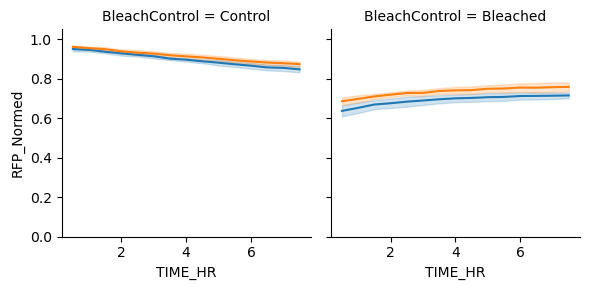

In [59]:
g = sns.FacetGrid(IntensitiesPostBleachMeans.query('TIME_HR < 8'), 
                  col = 'BleachControl', col_order = ['Control','Bleached'],
                  ylim = (0,1.05))

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HR', 
                y = 'RFP_Normed', 
                hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                errorbar = 'sd')

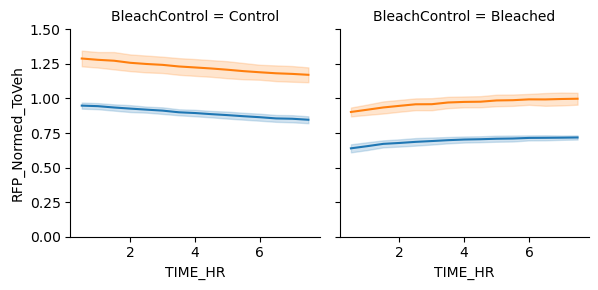

In [60]:
g = sns.FacetGrid(IntensitiesPostBleachMeans.query('TIME_HR < 8'), 
                  col = 'BleachControl', col_order = ['Control','Bleached'],
                  ylim = (0,1.5))

g.map_dataframe(sns.lineplot, 
                x = 'TIME_HR', 
                y = 'RFP_Normed_ToVeh', 
                hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                errorbar = 'sd')

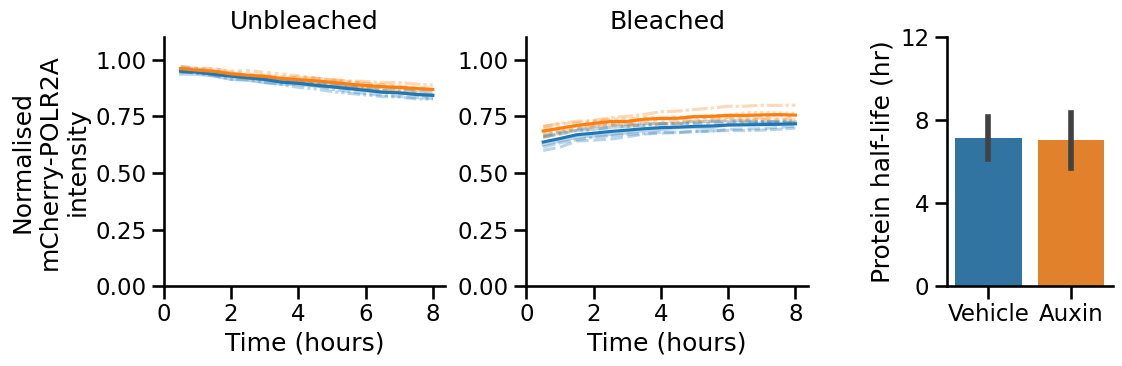

In [61]:
sns.set_context('talk')

f, a = plt.subplots(ncols = 3, figsize = (12,4))

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 style = 'REPLICATE',
                 ax = a[0],
                 legend = False,
                 alpha = 0.3)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 errorbar = None,
                 ax = a[0],
                 legend = False)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl != "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 style = 'REPLICATE',
                 ax = a[1],
                 legend = False,
                 alpha = 0.3)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Bleached"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 errorbar = None,
                 ax = a[1],
                 legend = False)

#a[0].set_box_aspect(1)
#a[1].set_box_aspect(1)

a[0].set_ylim(0,1.1)
a[1].set_ylim(0,1.1)

a[0].set_ylabel('Normalised\nmCherry-POLR2A\nintensity')
a[1].set_ylabel('')

a[0].set_xlabel('Time (hours)')
a[1].set_xlabel('Time (hours)')

a[0].set_xticks(np.linspace(0,8,5))
a[1].set_xticks(np.linspace(0,8,5))

a[0].set_title('Unbleached')
a[1].set_title('Bleached')

#sns.swarmplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[2], hue = 'Treatment')
h = sns.barplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[2], errorbar = 'sd',  hue = 'Treatment', dodge = False)
h.get_legend().remove()
h.set_box_aspect(1.5)

a[2].set_ylim(0,12)
a[2].set_yticks(np.linspace(0,12,4))
a[2].set_ylabel('Protein half-life (hr)')

a[2].set_xlabel('')
a[2].set_xticklabels(['Vehicle', 'Auxin'])

sns.despine()
plt.tight_layout()

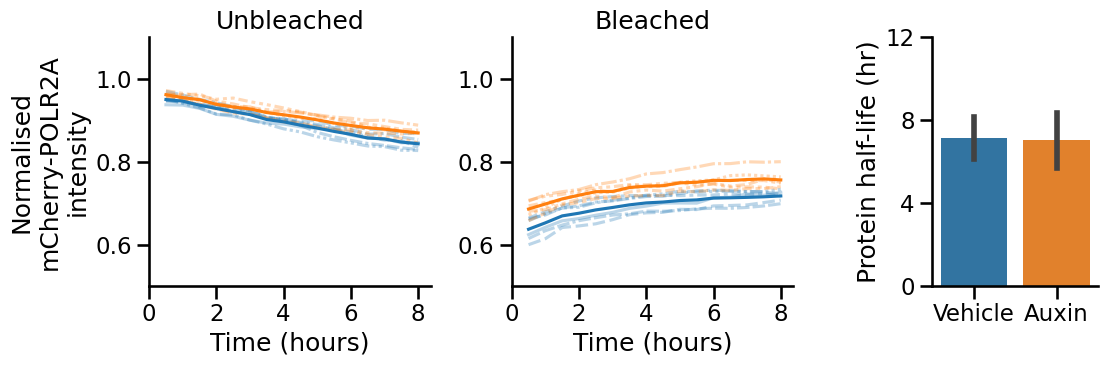

In [62]:
sns.set_context('talk')

f, a = plt.subplots(ncols = 3, figsize = (12,4))

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 style = 'REPLICATE',
                 ax = a[0],
                 legend = False,
                 alpha = 0.3)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 errorbar = None,
                 ax = a[0],
                 legend = False)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl != "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 style = 'REPLICATE',
                 ax = a[1],
                 legend = False,
                 alpha = 0.3)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Bleached"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 errorbar = None,
                 ax = a[1],
                 legend = False)

#a[0].set_box_aspect(1)
#a[1].set_box_aspect(1)

a[0].set_ylim(0.5,1.1)
a[1].set_ylim(0.5,1.1)

a[0].set_ylabel('Normalised\nmCherry-POLR2A\nintensity')
a[1].set_ylabel('')

a[0].set_xlabel('Time (hours)')
a[1].set_xlabel('Time (hours)')

a[0].set_xticks(np.linspace(0,8,5))
a[1].set_xticks(np.linspace(0,8,5))

a[0].set_title('Unbleached')
a[1].set_title('Bleached')

#sns.swarmplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[2], hue = 'Treatment')
h = sns.barplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[2], errorbar = 'sd',  hue = 'Treatment', dodge = False)
h.get_legend().remove()
h.set_box_aspect(1.5)

a[2].set_ylim(0,12)
a[2].set_yticks(np.linspace(0,12,4))
a[2].set_ylabel('Protein half-life (hr)')

a[2].set_xlabel('')
a[2].set_xticklabels(['Vehicle', 'Auxin'])

sns.despine()
plt.tight_layout()

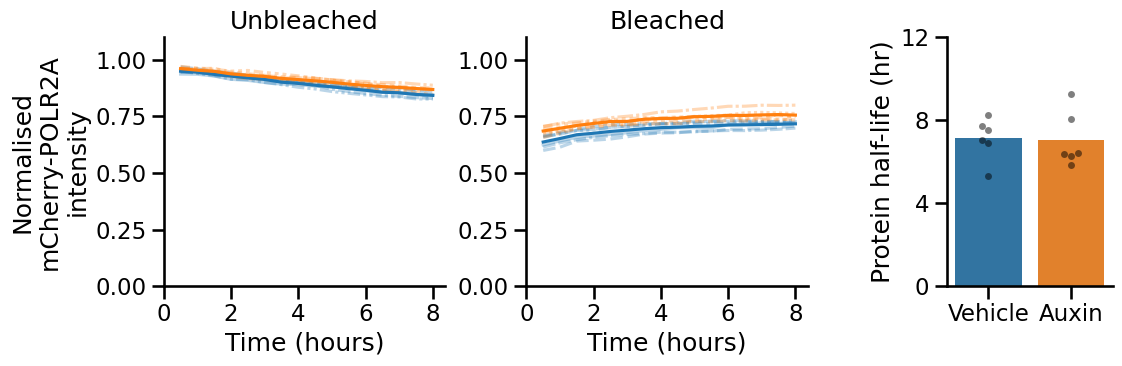

In [63]:
sns.set_context('talk')

f, a = plt.subplots(ncols = 3, figsize = (12,4))

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 style = 'REPLICATE',
                 ax = a[0],
                 legend = False,
                 alpha = 0.3)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 errorbar = None,
                 ax = a[0],
                 legend = False)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl != "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 style = 'REPLICATE',
                 ax = a[1],
                 legend = False,
                 alpha = 0.3)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Bleached"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'],
                 errorbar = None,
                 ax = a[1],
                 legend = False)

#a[0].set_box_aspect(1)
#a[1].set_box_aspect(1)

a[0].set_ylim(0,1.1)
a[1].set_ylim(0,1.1)

a[0].set_ylabel('Normalised\nmCherry-POLR2A\nintensity')
a[1].set_ylabel('')

a[0].set_xlabel('Time (hours)')
a[1].set_xlabel('Time (hours)')

a[0].set_xticks(np.linspace(0,8,5))
a[1].set_xticks(np.linspace(0,8,5))

a[0].set_title('Unbleached')
a[1].set_title('Bleached')

sns.swarmplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[2], alpha = 0.5, color = 'black')
h = sns.barplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[2], errorbar = None,  hue = 'Treatment', dodge = False)
h.get_legend().remove()
h.set_box_aspect(1.5)

a[2].set_ylim(0,12)
a[2].set_yticks(np.linspace(0,12,4))
a[2].set_ylabel('Protein half-life (hr)')

a[2].set_xlabel('')
a[2].set_xticklabels(['Vehicle', 'Auxin'])

sns.despine()
plt.tight_layout()

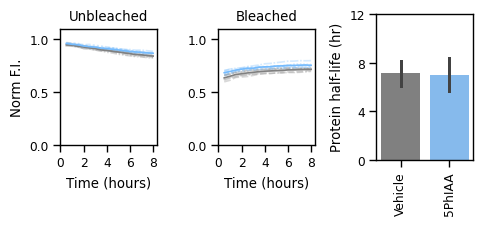

In [64]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (5,3))

pal = sns.color_palette(['grey', 'xkcd:sky blue'])

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'], palette = pal,
                 style = 'REPLICATE',
                 ax = a[0],
                 legend = False,
                 alpha = 0.3)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'], palette = pal,
                 errorbar = None,
                 ax = a[0],
                 legend = False)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl != "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'], palette = pal,
                 style = 'REPLICATE',
                 ax = a[1],
                 legend = False,
                 alpha = 0.3)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Bleached"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'], palette = pal,
                 errorbar = None,
                 ax = a[1],
                 legend = False)

a[0].set_box_aspect(1.2)
a[1].set_box_aspect(1.2)

a[0].set_ylim(0,1.1)
a[1].set_ylim(0,1.1)

a[0].set_ylabel('Norm F.I.')
a[1].set_ylabel('')

a[0].set_xlabel('Time (hours)')
a[1].set_xlabel('Time (hours)')

a[0].set_xticks(np.linspace(0,8,5))
a[1].set_xticks(np.linspace(0,8,5))

a[0].set_title('Unbleached')
a[1].set_title('Bleached')

#sns.swarmplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[2], hue = 'Treatment')
h = sns.barplot(Rates, 
                x = 'Treatment', 
                y = 'half-life (hr)', 
                ax = a[2], 
                errorbar = 'sd',  
                hue = 'Treatment', palette = pal, dodge = False)
h.get_legend().remove()
h.set_box_aspect(1.5)
h.tick_params(axis='x', labelrotation=90)

a[2].set_ylim(0,12)
a[2].set_yticks(np.linspace(0,12,4))
a[2].set_ylabel('Protein half-life (hr)')

a[2].set_xlabel('')
a[2].set_xticklabels(['Vehicle', '5PhIAA'])


plt.tight_layout()

plt.savefig('macmch_bleachchase.svg')

In [72]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

17-Dec-25 16:49:14 - matplotlib.font_manager - WARNING  - findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
17-Dec-25 16:49:14 - matplotlib.font_manager - WARNING  - findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
17-Dec-25 16:49:14 - matplotlib.font_manager - WARNING  - findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
17-Dec-25 16:49:14 - matplotlib.font_manager - WARNING  - findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
17-Dec-25 16:49:14 - matplotlib.font_manager - WARNING  - findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
17-Dec-25 16:49:14 - matplotlib.font_manager - WARNING  - findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
17-Dec-25 16:49:14 - m

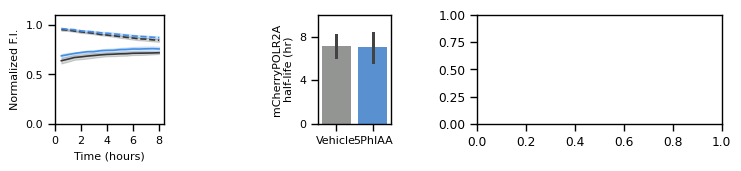

In [74]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8,1.8))

pal = sns.color_palette(['xkcd:dark grey', 'xkcd:dark sky blue'])
barpal = sns.color_palette(['xkcd:grey', 'xkcd:dark sky blue'])


g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Control"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'], palette = pal,
                 errorbar = 'sd',
                 linestyle = '--',
                 ax = a[0],
                 legend = False)

g = sns.lineplot(IntensitiesPostBleachMeans.query('TIME_HR <= 8 & BleachControl == "Bleached"'),
                 x = 'TIME_HR',
                 y = 'RFP_Normed',
                 hue = 'Treatment', hue_order = ['VEH', 'AUX'], palette = pal,
                 errorbar = 'sd',
                 ax = a[0],
                 legend = False)

a[0].set_box_aspect(1)

a[0].set_ylim(0,1.1)

a[0].set_ylabel('Normalized F.I.', fontsize = 8)

a[0].set_xlabel('Time (hours)', fontsize = 8)

a[0].set_xticks(np.linspace(0,8,5))

a[0].tick_params(axis='both', labelsize=8)

#a[0].set_title('Bleach recovery')

#sns.swarmplot(Rates, x = 'Treatment', y = 'half-life (hr)', ax = a[2], hue = 'Treatment')
h = sns.barplot(Rates, 
                x = 'Treatment', 
                y = 'half-life (hr)', 
                ax = a[1], 
                errorbar = 'sd',  
                hue = 'Treatment', palette = barpal, dodge = False)
h.get_legend().remove()
h.set_box_aspect(1.5)
#h.tick_params(axis='x', labelrotation=90)

a[1].set_ylim(0,10)
a[1].set_yticks(np.linspace(0,8,3))
a[1].set_ylabel('mCherryPOLR2A\nhalf-life (hr)', fontsize = 8)

a[1].set_xlabel('')
a[1].set_xticklabels(['Vehicle', '5PhIAA'], fontsize = 8)

a[1].tick_params(axis='both', labelsize=8)


plt.tight_layout()

plt.savefig('macmch_bleachchase_2cols.svg')

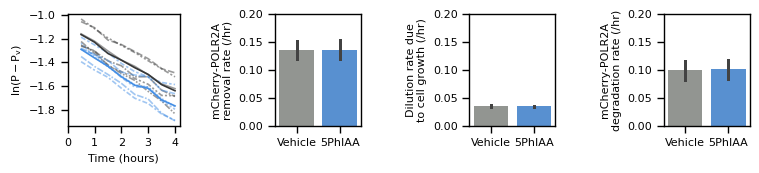

In [66]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 4, figsize = (8,1.8))

pal = sns.color_palette(['xkcd:dark grey', 'xkcd:dark sky blue'])
barpal = sns.color_palette(['xkcd:grey', 'xkcd:dark sky blue'])


sns.lineplot(NormalisedIntensities,
             x = 'Time_hr',
             y = 'Log_SubtractedIntensity', 
             hue = 'Treatment', hue_order = ['VEH', 'AUX'], palette = pal,
             style = 'Replicate',
             alpha = 0.5,
             legend = False,
             ax = a[0])

sns.lineplot(NormalisedIntensities,
             x = 'Time_hr',
             y = 'Log_SubtractedIntensity', 
             hue = 'Treatment', hue_order = ['VEH', 'AUX'], palette = pal,
             errorbar = None,
             legend = False,
             ax = a[0])

a[0].set_box_aspect(1)

a[0].set_ylabel('$ \mathregular{ln(P-P_v)} $', fontsize = 8)

a[0].set_xlabel('Time (hours)', fontsize = 8)

a[0].set_xticks(np.linspace(0,4,5))

a[0].tick_params(axis='both', labelsize=8)

h = sns.barplot(Rates, 
                x = 'Treatment', 
                y = 'RemovalRate_perhr', 
                ax = a[1], 
                errorbar = 'sd',  
                hue = 'Treatment', palette = barpal, dodge = False)
h.get_legend().remove()
h.set_box_aspect(1.3)

a[1].set_ylabel('mCherry-POLR2A\nremoval rate (/hr)', fontsize = 8)
a[1].set_xlabel('')
a[1].set_xticklabels(['Vehicle', '5PhIAA'], fontsize = 8)
a[1].tick_params(axis='both', labelsize=8)

h = sns.barplot(Rates, 
                x = 'Treatment', 
                y = 'GrowthRate_perhr', 
                ax = a[2], 
                errorbar = 'sd',  
                hue = 'Treatment', palette = barpal, dodge = False)
h.get_legend().remove()
h.set_box_aspect(1.3)

a[2].set_ylabel('Dilution rate due\nto cell growth (/hr)', fontsize = 8)
a[2].set_xlabel('')
a[2].set_xticklabels(['Vehicle', '5PhIAA'], fontsize = 8)
a[2].tick_params(axis='both', labelsize=8)

h = sns.barplot(Rates, 
                x = 'Treatment', 
                y = 'DegradationRate_perhr', 
                ax = a[3], 
                errorbar = 'sd',  
                hue = 'Treatment', palette = barpal, dodge = False)
h.get_legend().remove()
h.set_box_aspect(1.3)

a[3].set_ylabel('mCherry-POLR2A\ndegradation rate (/hr)', fontsize = 8)
a[3].set_xlabel('')
a[3].set_xticklabels(['Vehicle', '5PhIAA'], fontsize = 8)
a[3].tick_params(axis='both', labelsize=8)

a[1].set_ylim(0,0.2)
a[2].set_ylim(0,0.2)
a[3].set_ylim(0,0.2)

plt.tight_layout()

plt.savefig('bleach_chase_extended_data.svg')

In [67]:
Rates.columns.tolist()

['Experiment',
 'Well',
 'Treatment',
 'GrowthRate_perhr',
 'RemovalRate_perhr',
 'DegradationRate_perhr',
 'half-life (hr)']

In [68]:
mACmCh_BleachChase_ByExperiment = Rates.drop('Well', axis = 1).groupby(['Experiment','Treatment']).mean().reset_index()

In [69]:
mACmCh_BleachChase_ByExperiment.drop('Experiment', axis = 1).groupby('Treatment').mean()

,GrowthRate_perhr,RemovalRate_perhr,DegradationRate_perhr,half-life (hr)
Treatment,,,,
AUX,0.034835,0.136038,0.101203,7.032911
VEH,0.036136,0.135228,0.099092,7.131094


In [70]:
mACmCh_BleachChase_ByExperiment.drop('Experiment', axis = 1).groupby('Treatment').std()

,GrowthRate_perhr,RemovalRate_perhr,DegradationRate_perhr,half-life (hr)
Treatment,,,,
AUX,0.000735,0.011256,0.011242,0.858903
VEH,0.001302,0.014075,0.014524,0.940026


In [71]:
mACmCh_BleachChase_ByExperiment.to_csv('mACmCh_BleachChase_ByExperiment.csv')